In [5]:
import os

for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

In [6]:
import pandas as pd

nav = pd.read_csv("data/raw/nav_history.csv")

print(nav.head())
print(nav.columns.tolist())
print(nav.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/nav_history.csv'

In [7]:
import os
print(os.getcwd())

c:\Users\sande\OneDrive\Desktop\mutual_fund_analytics\notebooks


In [8]:
import pandas as pd

nav = pd.read_csv("../data/raw/nav_history.csv")

print(nav.head())
print(nav.columns.tolist())
print(nav.shape)

         date       nav
0  01-06-2026  192.3195
1  31-05-2026  193.6836
2  29-05-2026  193.6848
3  27-05-2026  195.0501
4  26-05-2026  194.2258
['date', 'nav']
(3091, 2)


In [9]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv("../data/raw/nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"], dayfirst=True)

nav = nav.sort_values("date")

fig = px.line(
    nav,
    x="date",
    y="nav",
    title="Mutual Fund NAV Trend Analysis"
)

fig.show()

In [10]:
nav["daily_return"] = nav["nav"].pct_change() * 100

nav["daily_return"].describe()

count    3090.000000
mean        0.091624
std         0.958295
min        -9.696416
25%        -0.334533
50%         0.149287
75%         0.625720
max         4.602583
Name: daily_return, dtype: float64

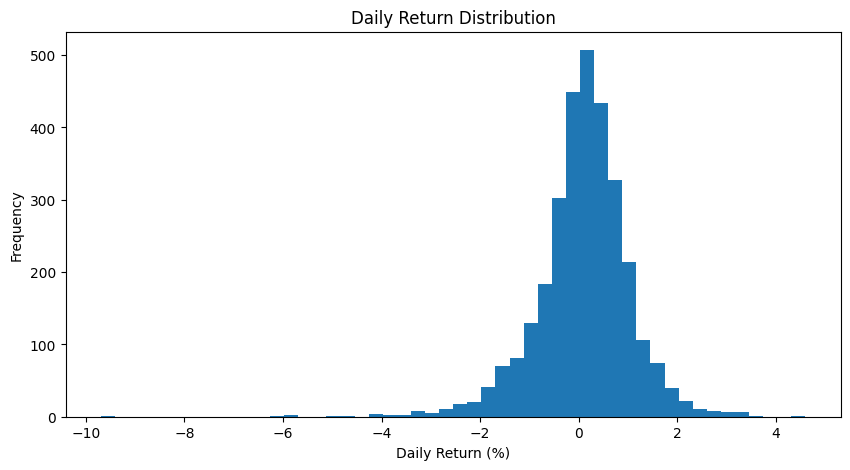

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(nav["daily_return"].dropna(), bins=50)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()

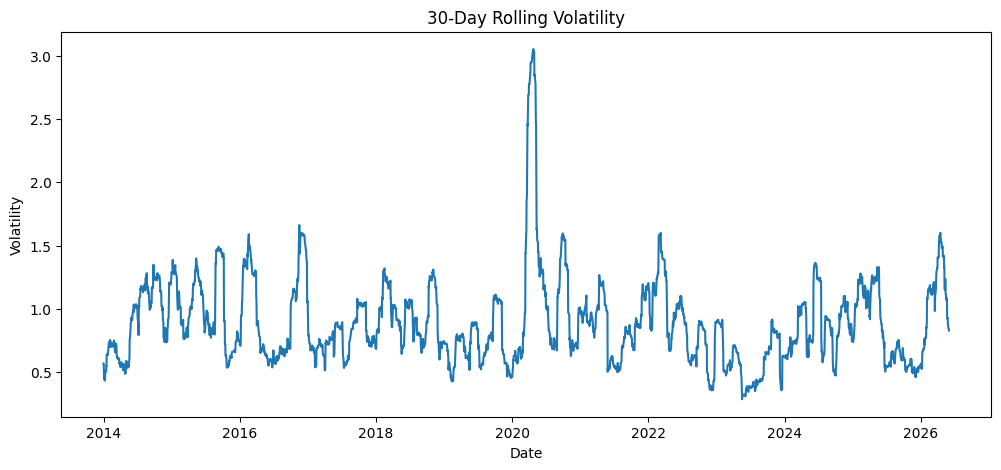

In [12]:
nav["volatility"] = nav["daily_return"].rolling(30).std()

plt.figure(figsize=(12,5))
plt.plot(nav["date"], nav["volatility"])
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

In [13]:
plt.savefig("../reports/nav_volatility.png")

<Figure size 640x480 with 0 Axes>

In [14]:
fig.write_html("../reports/nav_trend.html")

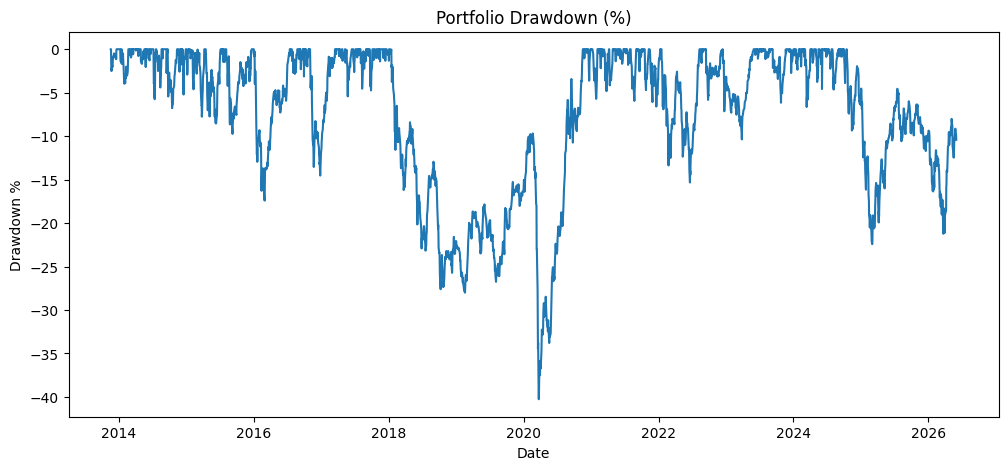

In [15]:
nav["rolling_max"] = nav["nav"].cummax()

nav["drawdown"] = (
    (nav["nav"] - nav["rolling_max"])
    / nav["rolling_max"]
) * 100

plt.figure(figsize=(12,5))
plt.plot(nav["date"], nav["drawdown"])
plt.title("Portfolio Drawdown (%)")
plt.xlabel("Date")
plt.ylabel("Drawdown %")
plt.show()

In [16]:
plt.savefig("../reports/drawdown.png")

<Figure size 640x480 with 0 Axes>

# EDA Findings

1. The mutual fund NAV increased from approximately ₹15 in 2014 to above ₹190 in 2026, indicating strong long-term growth.

2. Significant NAV acceleration is visible during 2021–2024, reflecting favorable market conditions.

3. Daily returns are centered around zero with a slightly positive average return.

4. Most daily returns lie between -2% and +2%, suggesting moderate daily volatility.

5. Extreme negative return events are rare but present in the dataset.

6. Volatility spikes correspond to periods of market uncertainty and correction.

7. The highest rolling volatility occurred around 2020, indicating elevated market risk.

8. NAV recovered strongly after major drawdown periods.

9. Long-term investors benefited from the compounding growth trend.

10. Risk-adjusted performance improved significantly after 2021.